In [1]:
import os
import sys
import torch
from tqdm import tqdm
from dotenv import load_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

load_dotenv()
sys.path.append(os.getenv("ROOT_PATH"))
import miso_utils.datasets as mud

def show_tensor_image(tensor):
 
    image = tensor.cpu().clone().detach()
    image = image.permute(1, 2, 0)
    
    if image.min() < 0 or image.max() > 1:
        image = (image - image.min()) / (image.max() - image.min())
    
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [2]:
import torch
from PIL import Image
import open_clip
device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k', precision='fp32')
clip_model = clip_model.to(device) 
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')

def ClipConcated(images, texts):
   
    img_emb = clip_model.encode_image(images)
    txt_emb = clip_model.encode_text(texts)
    
    # Normalize
    img_emb /= img_emb.norm(dim=-1, keepdim=True)
    txt_emb /= txt_emb.norm(dim=-1, keepdim=True)
    return torch.cat((img_emb, txt_emb), dim=1)

In [3]:
val_data = mud.create_val_dataset(os.getenv("VAL_PATH"), image_transform=preprocess)
train_data = mud.create_train_dataset(os.getenv("TRAIN_PATH"), image_transform=preprocess)

Files Left: 0it [00:00, ?it/s]

Files Left: 600it [00:06, 97.14it/s] 
Files Left: 9395it [01:32, 102.02it/s]


In [4]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusionMatrix(y_true, y_pred):
    labels = sorted(list(set(y_true)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

## ANN Model

In [6]:
# class ANNModel(nn.Module):
#     def __init__(self, input_dim=1024):
#         super(ANNModel, self).__init__()
        
#         # A simple architecture: Input -> Hidden -> Output
#         self.network = nn.Sequential(
#             nn.Linear(input_dim, 512),
#             nn.ReLU(),
#             nn.Dropout(0.2),      # Helps prevent overfitting on smaller datasets
#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Linear(256, 10), 
#             nn.Sigmoid(),    # Single output for binary classification
#             nn.Linear(10, 1),
#             # Note: No Sigmoid here if using nn.BCEWithLogitsLoss (recommended)
#         )

#     def forward(self, x):
#         return self.network(x)

#     def give_last_hidden(self, x):
#         for i in range(7):
#             x = self.network[i](x)
#         return x

class ANNModel(nn.Module):
    def __init__(self, input_dim=1024):
        super(ANNModel, self).__init__()
        
        # A simple architecture: Input -> Hidden -> Output
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),      # Helps prevent overfitting on smaller datasets
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128), 
            nn.ReLU(),
            nn.Linear(128, 10), 
            nn.Sigmoid(),    # Single output for binary classification
            nn.Linear(10, 1),
            # Note: No Sigmoid here if using nn.BCEWithLogitsLoss (recommended)
        )

    def forward(self, x):
        return self.network(x)

    def give_last_hidden(self, x):
        for i in range(11):
            x = self.network[i](x)
        return x

In [7]:
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import f1_score

def train_miso_model(ann_model, clip_model, clip_tokenizer, train_loader, val_loader, save_path, epochs=10, lr=1e-4, device="cuda"):
    ann_model.to(device)
    clip_model.to(device)
    clip_model.eval() 
    
    criterion = nn.BCEWithLogitsLoss(reduction='sum')
    optimizer = torch.optim.Adam(ann_model.parameters(), lr=lr)
    
    best_val_acc = 0.0
    print(f"Starting training on {device}...")

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        ann_model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        # Accumulators for Macro-F1
        train_preds_all = []
        train_labels_all = []
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in pbar:
            images = batch['img'].to(device)
            text_tokens = clip_tokenizer(batch['transcription']).to(device)
            labels = batch['indian_label'].to(device).float()

            optimizer.zero_grad()
            with torch.no_grad(), torch.amp.autocast('cuda'):
                features = ClipConcated(images, text_tokens) 
            
            logits = ann_model(features.float()).squeeze()
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_total += labels.size(0)
            
            preds = (torch.sigmoid(logits) > 0.5).float()
            train_correct += (preds == labels).sum().item()

            # Store predictions and labels for F1 calculation
            train_preds_all.extend(preds.cpu().detach().numpy().tolist())
            train_labels_all.extend(labels.cpu().detach().numpy().tolist())
            
            # Calculate current running Macro-F1
            current_train_f1 = f1_score(train_labels_all, train_preds_all, average='macro', zero_division=0)

            pbar.set_postfix(
                avg_loss=f"{train_loss/train_total:.4f}", 
                acc=f"{100*train_correct/train_total:.2f}%",
                macro_f1=f"{current_train_f1:.4f}"
            )

        # --- VALIDATION PHASE ---
        ann_model.eval()
        val_loss, val_total, val_correct = 0.0, 0, 0
        
        val_preds_all = []
        val_labels_all = []
        
        with torch.no_grad():
            vbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
            for batch in vbar:
                images = batch['img'].to(device)
                text_tokens = clip_tokenizer(batch['transcription']).to(device)
                labels = batch['indian_label'].to(device).float()

                with torch.amp.autocast('cuda'):
                    features = ClipConcated(images, text_tokens)
                
                logits = ann_model(features.float()).squeeze()
                loss = criterion(logits, labels)
                
                val_loss += loss.item()
                val_total += labels.size(0)
                
                preds = (torch.sigmoid(logits) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                
                # Store predictions and labels for F1 calculation
                val_preds_all.extend(preds.cpu().detach().numpy().tolist())
                val_labels_all.extend(labels.cpu().detach().numpy().tolist())
                
                current_val_f1 = f1_score(val_labels_all, val_preds_all, average='macro', zero_division=0)
                
                vbar.set_postfix(
                    avg_loss=f"{val_loss/val_total:.4f}", 
                    acc=f"{100*val_correct/val_total:.2f}%",
                    macro_f1=f"{current_val_f1:.4f}"
                )

        epoch_val_acc = 100 * val_correct / val_total
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            # You can also choose to save based on best Macro-F1 by changing the condition above
            torch.save(ann_model.state_dict(), save_path + 'best_miso_model.pt')
            print(f"--> Saved Best Model (Val Acc: {best_val_acc:.2f}%, Val Macro-F1: {current_val_f1:.4f})")

        print("")

    # --- FINAL EVALUATION ---
    checkpoint = torch.load(save_path + 'best_miso_model.pt', map_location=device)
    ann_model.load_state_dict(checkpoint)

    y_preds = []
    y_true = []

    with torch.no_grad():
        for batch in val_loader:
            images = batch['img'].to(device)
            text_tokens = clip_tokenizer(batch['transcription']).to(device)
            labels = batch['indian_label'].to(device).float()
            
            with torch.amp.autocast('cuda'):
                features = ClipConcated(images, text_tokens)
            
            logits = ann_model(features.float()).squeeze()
               
            preds = (torch.sigmoid(logits) > 0.5).float()

            y_preds.extend(preds.cpu().detach().int().numpy().tolist())
            y_true.extend(labels.cpu().detach().int().numpy().tolist())

    plot_confusionMatrix(y_true, y_preds)
    
    final_f1 = f1_score(y_true, y_preds, average='macro', zero_division=0)
    print(f"Final Best Model Macro-F1 on Validation Set: {final_f1:.4f}")
    
    return ann_model

Starting training on cuda...


Epoch 1/20 [Val]: 100%|██████████| 10/10 [00:01<00:00,  7.30it/s, acc=74.67%, avg_loss=0.5794, macro_f1=0.6017]


--> Saved Best Model (Val Acc: 74.67%, Val Macro-F1: 0.6017)



Epoch 2/20 [Val]: 100%|██████████| 10/10 [00:00<00:00, 13.98it/s, acc=79.00%, avg_loss=0.4905, macro_f1=0.7200]


--> Saved Best Model (Val Acc: 79.00%, Val Macro-F1: 0.7200)



...

Epoch 16/20 [Val]: 100%|██████████| 10/10 [00:01<00:00,  7.06it/s, acc=79.17%, avg_loss=0.5795, macro_f1=0.7412]


Epoch 17/20 [Val]: 100%|██████████| 10/10 [00:00<00:00, 10.13it/s, acc=79.17%, avg_loss=0.6018, macro_f1=0.7492]


Epoch 18/20 [Val]: 100%|██████████| 10/10 [00:00<00:00, 12.99it/s, acc=78.33%, avg_loss=0.6369, macro_f1=0.7230]


Epoch 19/20 [Val]: 100%|██████████| 10/10 [00:00<00:00, 13.94it/s, acc=78.33%, avg_loss=0.6315, macro_f1=0.7313]


Epoch 20/20 [Val]: 100%|██████████| 10/10 [00:00<00:00, 12.69it/s, acc=78.33%, avg_loss=0.6280, macro_f1=0.7332]


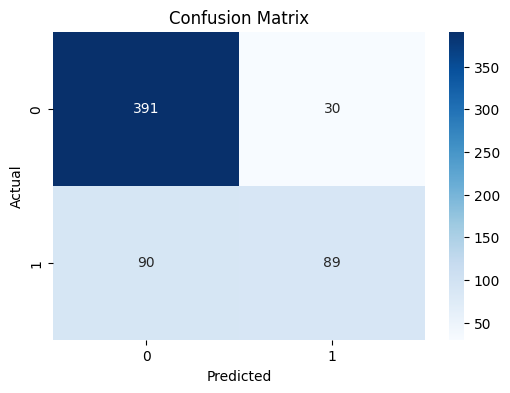

Final Best Model Macro-F1 on Validation Set: 0.7321


ANNModel(
  (network): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=256, bias=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
    (10): Sigmoid()
    (11): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [8]:
ann_model = ANNModel()
train_miso_model(ann_model,clip_model,clip_tokenizer,train_loader,val_loader,save_path=os.getenv("WEIGHTS_PATH") + "/ClipConcatAnn/",epochs = 20,lr = 1e-4 * 5)

In [ ]:
import numpy as np
device = "cuda" if torch.cuda.is_available() else "cpu"
chk = torch.load(os.getenv("WEIGHTS_PATH") + "/ClipConcatAnn/" + "best_miso_model.pt")
model = ANNModel()
model.load_state_dict(chk)
model = model.to(device)

clipclip_smalls = []
clipclip_smalls_labels = []

model.eval()
clip_model.eval()

model.eval()
for batch in tqdm(train_loader):
    images = batch['img'].to(device)
    text_tokens = clip_tokenizer(batch['transcription']).to(device)
    labels = batch['indian_label'].to(device).float()
    with torch.no_grad():
        features = ClipConcated(images, text_tokens)
    
    logits = model.give_last_hidden(features.float()).squeeze()
    clipclip_smalls.extend([logits[i].detach().cpu().numpy() for i in range(logits.shape[0])])
    clipclip_smalls_labels.extend([labels[i].detach().cpu().numpy() for i in range(labels.shape[0])])

In [12]:
clipclip_smalls_labels = np.stack(clipclip_smalls_labels)
clipclip_smalls = np.stack(clipclip_smalls)

In [13]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(clipclip_smalls)

# 2. Fit PCA
pca = PCA()
pca.fit(X_scaled)

# 3. Calculate Variance Percentages
variance_percentages = pca.explained_variance_ratio_ * 100

for i, var in enumerate(variance_percentages):
    print(f"Principal Component {i+1}: {var:.2f}%")

Principal Component 1: 99.84%
Principal Component 2: 0.16%
Principal Component 3: 0.01%
Principal Component 4: 0.00%
Principal Component 5: 0.00%
Principal Component 6: 0.00%
Principal Component 7: 0.00%
Principal Component 8: 0.00%
Principal Component 9: 0.00%
Principal Component 10: 0.00%


In [14]:
import gc

del clipclip_smalls
del clipclip_smalls_labels

## Neural Descion Tree

In [15]:
class NeuralDesicionTreeNode():
    def __init__(self, BaseModelClass):
        self.BaseModelClass = BaseModelClass
        self.model = BaseModelClass()

        self.left = None
        self.right = None
        self.isLeaf = False

    def train_node(self, train_loader, val_loader=None, epochs=50, lr=1e-2, device="cuda", save_path="./temp/", patience=3):
        self.model.to(device)
        os.makedirs(save_path, exist_ok=True)

        criterion = nn.BCEWithLogitsLoss(reduction='sum')
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        # Initialize the scheduler: factor=0.5 halves the LR, mode='min' watches for loss decreasing
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience)

        best_val_acc = 0.0
        print(f"Starting training on {device}...")

        for epoch in range(epochs):
            self.model.train()
            train_loss, train_correct, train_total = 0.0, 0, 0

            pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
            for batch in pbar:
                features = batch['X'].to(device)
                labels = batch['y'].to(device).float()

                optimizer.zero_grad()
                logits = self.model(features.float()).squeeze()

                # Handle single-item batch squeezing issue
                if logits.dim() == 0: logits = logits.unsqueeze(0) 

                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                train_total += labels.size(0)

                preds = (torch.sigmoid(logits) > 0.5).float()
                train_correct += (preds == labels).sum().item()

                pbar.set_postfix(
                    avg_loss=f"{train_loss/train_total:.4f}", 
                    acc=f"{100*train_correct/train_total:.2f}%"
                )

            epoch_train_loss = train_loss / train_total

            # --- VALIDATION PHASE ---
            if val_loader is not None:
                self.model.eval()
                val_loss, val_total, val_correct = 0.0, 0, 0

                with torch.no_grad():
                    vbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
                    for batch in vbar:
                        features = batch['X'].to(device)
                        labels = batch['y'].to(device).float()

                        logits = self.model(features.float()).squeeze()
                        if logits.dim() == 0: logits = logits.unsqueeze(0)

                        loss = criterion(logits, labels)

                        val_loss += loss.item()
                        val_total += labels.size(0)

                        preds = (torch.sigmoid(logits) > 0.5).float()
                        val_correct += (preds == labels).sum().item()

                        vbar.set_postfix(
                            avg_loss=f"{val_loss/val_total:.4f}", 
                            acc=f"{100*val_correct/val_total:.2f}%"
                        )

                epoch_val_acc = 100 * val_correct / val_total
                epoch_val_loss = val_loss / val_total

                # Step the scheduler based on validation loss
                scheduler.step(epoch_val_loss)

                if epoch_val_acc >= best_val_acc:
                    best_val_acc = epoch_val_acc
                    torch.save(self.model.state_dict(), save_path + 'best_miso_model.pt')
            else:
                # Fallback: Save latest epoch and step scheduler on train loss
                torch.save(self.model.state_dict(), save_path + 'best_miso_model.pt')
                scheduler.step(epoch_train_loss)

            # Print current Learning Rate so you can track the scheduler's behavior
            current_lr = optimizer.param_groups[0]['lr']
            print(f"End of Epoch {epoch+1}. Current Learning Rate: {current_lr:.6f}")

        # Load best model weights before exiting
        checkpoint = torch.load(save_path + 'best_miso_model.pt', map_location=device)
        self.model.load_state_dict(checkpoint)
       
    def _entropy(self, y):
        if len(y) == 0: return 0.0
        p = (y == 1).sum().float() / len(y)
        if p == 0 or p == 1: return 0.0
        return -p * torch.log2(p) - (1 - p) * torch.log2(1 - p)

    def _split_indices(self, dataset, feature_idx, threshold, device="cuda"):
        left_indices, right_indices = [], []
        if len(dataset) == 0: return left_indices, right_indices
        
        self.model.eval()
        loader = DataLoader(dataset, batch_size=64, shuffle=False)
        current_idx = 0
        
        with torch.no_grad():
            for batch in loader:
                x = batch['X'].to(device)
                hidden = self.model.give_last_hidden(x.float())
                
                condition = hidden[:, feature_idx] <= threshold
                
                for val in condition:
                    if val.item():
                        left_indices.append(current_idx)
                    else:
                        right_indices.append(current_idx)
                    current_idx += 1
                    
        return left_indices, right_indices

    def fit(self, train_dataset, val_dataset,max_bins = 8, current_depth=0, max_depth=3, min_samples_split=20, device="cuda"):

        # --- 1. BASE CASES ---
        labels = torch.tensor([train_dataset[i]['y'] for i in range(len(train_dataset))])
        self.is_pure = len(torch.unique(labels)) == 1
        
        if self.is_pure or current_depth >= max_depth or len(train_dataset) < min_samples_split:
            self.isLeaf = True
            if self.is_pure: 
                self.label = train_dataset[0]['y']
            else:
                # Majority voting if not pure but forced to be a leaf
                self.label = torch.mode(labels).values.item()
            
            self.model = None
            return

        # --- 2. TRAIN CURRENT NODE ---
        train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
        if len(val_dataset) > 10: 
            val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
        else:
            val_loader = None 
            
        self.train_node(train_loader, val_loader, device=device)

        # --- 3. GET REPRESENTATIONS & CALCULATE SPLIT ---
        self.model.eval()
        all_hidden = []
        with torch.no_grad():
            for batch in DataLoader(train_dataset, batch_size=64, shuffle=False):
                h = self.model.give_last_hidden(batch['X'].float().to(device))
                all_hidden.append(h.cpu())
                
        vectors = torch.cat(all_hidden, dim=0)
        
        best_ig = -1.0
        best_feature_idx = None
        best_threshold = None
        base_entropy = self._entropy(labels)

        # Iterate through features to find best Information Gain
        for feature_idx in range(vectors.shape[1]):
            feature_vals = vectors[:, feature_idx].float() # Quantile requires float32
            
            # --- BINNING LOGIC ---
            unique_vals = torch.unique(feature_vals)
            
            if len(unique_vals) <= max_bins:
                thresholds = unique_vals
            else:
                # Generate quantiles (e.g., for max_bins=10, we want the 10th, 20th... 90th percentiles)
                # We slice [1:-1] to avoid testing the absolute min and max, which create empty splits
                q = torch.linspace(0, 1, steps=max_bins + 2)[1:-1] 
                
                # Calculate thresholds and call unique() again in case multiple quantiles 
                # fall on the exact same value (happens in dense data clusters)
                thresholds = torch.unique(torch.quantile(feature_vals, q))
            # ---------------------
            
            for t in thresholds:
                left_mask = feature_vals <= t
                right_mask = ~left_mask
                
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue
                    
                y_left = labels[left_mask]
                y_right = labels[right_mask]
                
                p_left = len(y_left) / len(labels)
                p_right = len(y_right) / len(labels)
                
                ig = base_entropy - (p_left * self._entropy(y_left) + p_right * self._entropy(y_right))
                
                if ig > best_ig:
                    best_ig = ig
                    best_feature_idx = feature_idx
                    best_threshold = t

        # Infinite Recursion Safety Net
        if best_ig <= 0:
            self.isLeaf = True
            self.label = torch.mode(labels).values.item()
            return

        self.split_feature_idx = best_feature_idx
        self.split_threshold = best_threshold.to(device)

        # --- 4. ROUTE DATASETS ---
        train_left_idx, train_right_idx = self._split_indices(train_dataset, best_feature_idx, best_threshold, device)
        val_left_idx, val_right_idx = self._split_indices(val_dataset, best_feature_idx, best_threshold, device)

        # --- 5. RECURSE ---
        self.left = NeuralDesicionTreeNode(self.BaseModelClass)
        self.right = NeuralDesicionTreeNode(self.BaseModelClass)
        
        self.left.fit(torch.utils.data.Subset(train_dataset, train_left_idx), 
                      torch.utils.data.Subset(val_dataset, val_left_idx),max_bins,
                      current_depth + 1, max_depth, min_samples_split, device)
                      
        self.right.fit(torch.utils.data.Subset(train_dataset, train_right_idx), 
                       torch.utils.data.Subset(val_dataset, val_right_idx),max_bins, 
                       current_depth + 1, max_depth, min_samples_split, device)
    
    def predict(self, x, device="cuda"):
        """
        Classifies a batch of inputs.
        Args:
            x: Tensor of inputs [batch_size, ...]
        Returns:
            Tensor of predicted labels [batch_size]
        """
        batch_size = x.shape[0]
        preds = torch.zeros(batch_size, device=device)
        
        # --- 1. BASE CASE: LEAF NODE ---
        if self.isLeaf:
            # Return a tensor filled with this leaf's label
            return preds.fill_(self.label)
            
        # --- 2. ROUTING ---
        self.model.eval()
        with torch.no_grad():
            x = x.to(device)
            hidden = self.model.give_last_hidden(x.float())
            
            # Determine which samples go left vs right
            left_mask = hidden[:, self.split_feature_idx] <= self.split_threshold
            right_mask = ~left_mask
            
            # --- 3. RECURSE & RECOMBINE ---
            if left_mask.any():
                # Pass only the subset of 'x' that belongs to the left child
                preds[left_mask] = self.left.predict(x[left_mask], device)
                
            if right_mask.any():
                # Pass only the subset of 'x' that belongs to the right child
                preds[right_mask] = self.right.predict(x[right_mask], device)
                
        return preds

In [16]:
from torch.utils.data import Dataset
class NeuralTreeDataset(Dataset):
    def __init__(self,basedataset):
        super().__init__()

        self.data = []
        self.labels = []

        for item in tqdm(basedataset):
            images = item['img'].unsqueeze(0).to(device)
            text_tokens = clip_tokenizer(item['transcription']).to(device)
            labels = float(item['indian_label'])
            with torch.no_grad(), torch.amp.autocast('cuda'):
                features = ClipConcated(images, text_tokens) 
            
            self.data.append(features[0])
            self.labels.append(labels)

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return {
            "X": self.data[index],
            "y": self.labels[index],
        }

In [17]:
neuralValDataset = NeuralTreeDataset(val_data)
neuralTrainDataset = NeuralTreeDataset(train_data)

import gc 

del clip_model
del clip_tokenizer

100%|██████████| 9395/9395 [03:55<00:00, 39.96it/s]


In [18]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# 1. Get indices and labels
indices = list(range(len(neuralTrainDataset)))
labels = neuralTrainDataset.labels 

# 2. Perform the stratified split
train_indices, val_indices = train_test_split(
    indices, 
    test_size=0.2, 
    stratify=labels, 
    random_state=42 # Set a seed for reproducibility
)

# 3. Create the PyTorch Subsets
tree_train_subset = Subset(neuralTrainDataset, train_indices)
tree_val_subset = Subset(neuralTrainDataset, val_indices)

# Verify the lengths
print(f"Original size: {len(neuralTrainDataset)}")
print(f"Train subset size: {len(tree_train_subset)}")
print(f"Val subset size: {len(tree_val_subset)}")

Original size: 9395
Train subset size: 7516
Val subset size: 1879


In [24]:
treeClassifer = NeuralDesicionTreeNode(BaseModelClass = ANNModel)
treeClassifer.fit(tree_train_subset,tree_val_subset,min_samples_split=20,max_depth=7,max_bins=20)

Starting training on cuda...


Epoch 1/50 [Train]:   0%|          | 0/59 [00:00<?, ?it/s, acc=74.22%, avg_loss=0.6203]

Epoch 1/50 [Val]: 100%|██████████| 15/15 [00:00<00:00, 239.02it/s, acc=76.48%, avg_loss=0.4889]


End of Epoch 1. Current Learning Rate: 0.010000


Epoch 2/50 [Val]: 100%|██████████| 15/15 [00:00<00:00, 225.66it/s, acc=76.21%, avg_loss=0.4816]


...

End of Epoch 48. Current Learning Rate: 0.000020


Epoch 49/50 [Val]: 100%|██████████| 5/5 [00:00<00:00, 328.52it/s, acc=59.47%, avg_loss=0.6918]


End of Epoch 49. Current Learning Rate: 0.000010


Epoch 50/50 [Val]: 100%|██████████| 5/5 [00:00<00:00, 329.47it/s, acc=59.47%, avg_loss=0.6918]


End of Epoch 50. Current Learning Rate: 0.000010


Evaluating tree...
Overall Accuracy: 78.17%
Macro F1 Score: 0.7421


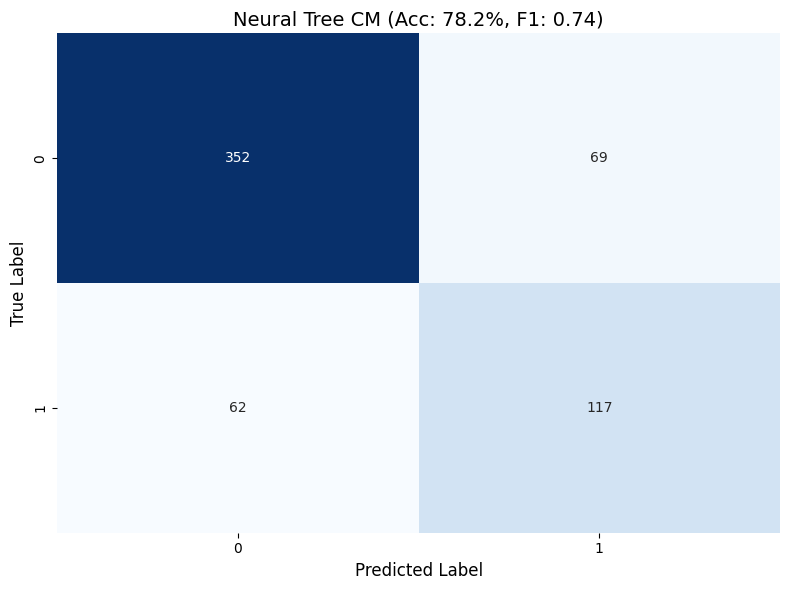

(0.7816666666666666,
 0.7421048314330243,
 array([[352,  69],
        [ 62, 117]]))

In [25]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from torch.utils.data import DataLoader

def evaluate_and_plot(tree_root, dataset, batch_size=64, device="cuda"):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_preds = []
    all_labels = []

    print("Evaluating tree...")
    with torch.no_grad():
        for batch in loader:
            x = batch['X'].to(device)
            labels = batch['y'].cpu().numpy()
            
            preds = tree_root.predict(x, device=device).cpu().numpy()
            
            all_preds.extend(preds)
            all_labels.extend(labels)

    # 1. Calculate Metrics
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    print(f"Overall Accuracy: {acc * 100:.2f}%")
    print(f"Macro F1 Score: {macro_f1:.4f}")

    # 2. Generate Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    # 3. Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Neural Tree CM (Acc: {acc*100:.1f}%, F1: {macro_f1:.2f})', fontsize=14)
    plt.tight_layout() # Added for better mobile/small screen rendering
    plt.show()

    return acc, macro_f1, cm

evaluate_and_plot(treeClassifer,neuralValDataset)

## Sklearn Classifiers

In [ ]:
from sklearn.utils import all_estimators

# Filter for 'classifier' type estimators
classifiers = all_estimators(type_filter='classifier')

for name, ClassifierClass in classifiers:
    try:
        # Initialize the classifier
        clf = ClassifierClass()
        print(f"Testing: {name}")
        
        # Example: clf.fit(X_train, y_train)
    except Exception as e:
        # Some classifiers require specific parameters during initialization
        print(f"Could not initialize {name}: {e}")

Testing: AdaBoostClassifier
Testing: BaggingClassifier
Testing: BernoulliNB
Testing: CalibratedClassifierCV
Testing: CategoricalNB
Testing: ClassifierChain
Testing: ComplementNB
Testing: DecisionTreeClassifier
Testing: DummyClassifier
Testing: ExtraTreeClassifier
Testing: ExtraTreesClassifier
Could not initialize FixedThresholdClassifier: FixedThresholdClassifier.__init__() missing 1 required positional argument: 'estimator'
Testing: GaussianNB
Testing: GaussianProcessClassifier
Testing: GradientBoostingClassifier
Testing: HistGradientBoostingClassifier
Testing: KNeighborsClassifier
Testing: LabelPropagation
Testing: LabelSpreading
Testing: LinearDiscriminantAnalysis
Testing: LinearSVC
Testing: LogisticRegression
Testing: LogisticRegressionCV
Testing: MLPClassifier
Could not initialize MultiOutputClassifier: MultiOutputClassifier.__init__() missing 1 required positional argument: 'estimator'
Testing: MultinomialNB
Testing: NearestCentroid
Testing: NuSVC
Could not initialize OneVsOneCla

c:\Users\ayush\OneDrive\Desktop\Miso ai\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


In [ ]:
import torch
import numpy as np

def extract_features(loader, device="cuda"):
    X_list = []
    y_list = []
    
    # Ensure models are on the correct device and in eval mode
    # clip_model should be handled inside your ClipConcated or global scope
    ann_model.eval() 
    
    print(f"Extracting features from {len(loader)} batches...")
    
    with torch.no_grad():
        for batch in loader:
            images = batch['img'].to(device)
            # Ensure text_tokens is generated correctly based on your tokenizer setup
            text_tokens = clip_tokenizer(batch['transcription']).to(device)
            labels = batch['indian_label'].to(device).float()
            
            # 1. Extract Multimodal Features
            with torch.amp.autocast('cuda'):
                # Using your ClipConcated function to get the (batch, 1024) features
                features = ClipConcated(images, text_tokens)
            
            # 2. Move to CPU and convert to NumPy
            X_list.append(features.cpu().float().numpy())
            # Ensure labels are (batch_size,) for sklearn compatibility
            y_list.append(labels.cpu().numpy().ravel())
            
    # 3. Stack all batches into final arrays
    X_final = np.vstack(X_list)
    y_final = np.concatenate(y_list)
    
    return X_final, y_final

# --- Usage ---
# Extracting your training and validation sets
X_train, y_train = extract_features(train_loader)
X_val, y_val = extract_features(val_loader)

print(f"Extraction Complete!")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}   | y_val shape: {y_val.shape}")

Extracting features from 147 batches...
Extracting features from 10 batches...
Extraction Complete!
X_train shape: (9395, 1024) | y_train shape: (9395,)
X_val shape: (600, 1024)   | y_val shape: (600,)


In [ ]:
from sklearn.utils import all_estimators
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import warnings

# Suppress warnings from models that don't converge or have zero-division in metrics
warnings.filterwarnings('ignore')

print(f"{'Classifier':<25} | {'Acc':<6} | {'Prec':<6} | {'Rec':<6} | {'F1':<6}")
print("-" * 65)
# 2. Setup iteration
classifiers = all_estimators(type_filter='classifier')
results = []

for name, ClassifierClass in classifiers:
    # Skip meta-classifiers and known incompatible models
    if name in ['OutputCodeClassifier', 'OneVsOneClassifier', 'OneVsRestClassifier', 
                'VotingClassifier', 'StackingClassifier', 'ClassifierChain', 'NuSVC']:
        continue
        
    try:
        clf = ClassifierClass()
        clf.fit(X_train, y_train)
        
        preds = clf.predict(X_val)
        
        # Calculate metrics (using 'binary' since your labels are likely 0/1)
        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds, average='binary')
        rec = recall_score(y_val, preds, average='binary')
        f1 = f1_score(y_val, preds, average='binary')
        
        print(f"{name:<25} | {acc:.3f} | {prec:.3f} | {rec:.3f} | {f1:.3f}")
        
        results.append({
            "Model": name, 
            "Accuracy": acc, 
            "Precision": prec, 
            "Recall": rec, 
            "F1-Score": f1
        })
        
    except Exception:
        # Skip models that require specific parameters or fail on (n, 1024)
        continue


# 3. Final Summary Table
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("\nSorted by F1-Score (Top 10):")
print(df_results.head(10).to_string(index=False))

Classifier                | Acc    | Prec   | Rec    | F1    
-----------------------------------------------------------------
AdaBoostClassifier        | 0.760 | 0.636 | 0.458 | 0.532
BaggingClassifier         | 0.743 | 0.640 | 0.318 | 0.425
BernoulliNB               | 0.755 | 0.577 | 0.670 | 0.620
CalibratedClassifierCV    | 0.788 | 0.713 | 0.486 | 0.578
CategoricalNB             | 0.702 | 0.000 | 0.000 | 0.000
DecisionTreeClassifier    | 0.685 | 0.472 | 0.464 | 0.468
DummyClassifier           | 0.702 | 0.000 | 0.000 | 0.000
ExtraTreeClassifier       | 0.630 | 0.365 | 0.324 | 0.343
ExtraTreesClassifier      | 0.738 | 0.824 | 0.156 | 0.263
GaussianNB                | 0.758 | 0.582 | 0.676 | 0.625
GaussianProcessClassifier | 0.795 | 0.741 | 0.480 | 0.583
GradientBoostingClassifier | 0.768 | 0.669 | 0.441 | 0.532
HistGradientBoostingClassifier | 0.778 | 0.692 | 0.464 | 0.555
KNeighborsClassifier      | 0.752 | 0.585 | 0.575 | 0.580
LabelPropagation          | 0.750 | 0.579 | 0.592 | 0.